In [ ]:
# Projet: Estimation du traffic routier 

In [84]:
# Importation des modules et packages necessaires:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv2D, MaxPooling2D, Flatten, MaxPool1D, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import callbacks
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.optimizers.schedules import ExponentialDecay

In [85]:
# Impotration des données
data = pd.read_csv('D:\\DOCUMENTS\\PROJETS\\Estimation-du-traffic-routier---ATUT2025\\data\\traffic.csv')

# Exploration des données: La base contient le nombre de vehicule à 4 carreours toutes les heures
Notre dataset contient les variables suivantes:
- DateTime: la date de l'observation
- Junction: le numero du carrefour
- Vehicles: Le nombre de vehicules qui ont traversé le carrefour pendant l'heure d'observation

In [86]:
data.head(2)

,DateTime,Junction,Vehicles,ID
0,11/1/2015 0:00,1,15,20151101001
1,11/1/2015 1:00,1,13,20151101011


In [87]:
data.dtypes

DateTime      str
Junction    int64
Vehicles    int64
ID          int64
dtype: object

In [ ]:
# Conversion du type de la variable DateTime en datetime et suppression de la variable ID

In [88]:
data["DateTime"] = pd.to_datetime(data["DateTime"])
data.drop("ID", axis=1, inplace=True)

data.dtypes

DateTime    datetime64[us]
Junction             int64
Vehicles             int64
dtype: object

In [89]:
data.head(2)

,DateTime,Junction,Vehicles
0,2015-11-01 00:00:00,1,15
1,2015-11-01 01:00:00,1,13


In [90]:
data = data.rename(columns={'Junction': 'Jonction', 'Vehicles':'Vehicules', 'DateTime':'DateHeure'})
new_data = data.copy()

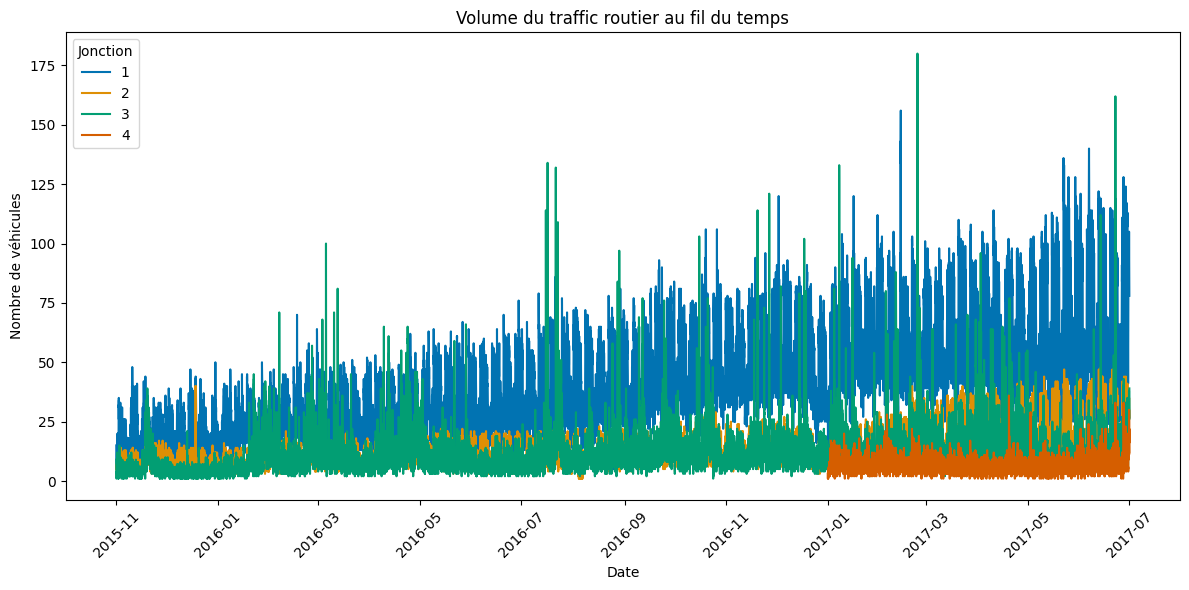

In [91]:
# Visualisation des données
def plot_traffic(data):
    plt.figure(figsize=(12, 6))
    sns.lineplot(x= data['DateHeure'], y='Vehicules', data=data, hue='Jonction', palette='colorblind')
    plt.title('Volume du traffic routier au fil du temps')
    plt.xlabel('Date')
    plt.ylabel('Nombre de véhicules')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_traffic(new_data)

In [92]:
new_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   DateHeure  48120 non-null  datetime64[us]
 1   Jonction   48120 non-null  int64         
 2   Vehicules  48120 non-null  int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 1.1 MB


# Feature engineering: 
Ici je vais construire de nouvelles variables pour extraire des informations surtout à partir de la colonne date.

A partir de la visualisation précédente, on observe que:
- Le nombre de véhicule à la jonction 1 montre une tendence haussière
- Les données sur la jonctions 4, commence seulement à partir de janvier 2017

Donc pour avoir suffisament d'informations, on va devoir extraire les années, les mois, les jours et heures


In [93]:
new_data["Annee"] = pd.to_datetime(new_data["DateHeure"]).dt.year
new_data["Mois"] = pd.to_datetime(new_data["DateHeure"]).dt.month
new_data["Jour"] = pd.to_datetime(new_data["DateHeure"]).dt.day
new_data["Heure"] = pd.to_datetime(new_data["DateHeure"]).dt.hour

new_data.head(2)

,DateHeure,Jonction,Vehicules,Annee,Mois,Jour,Heure
0,2015-11-01 00:00:00,1,15,2015,11,1,0
1,2015-11-01 01:00:00,1,13,2015,11,1,1


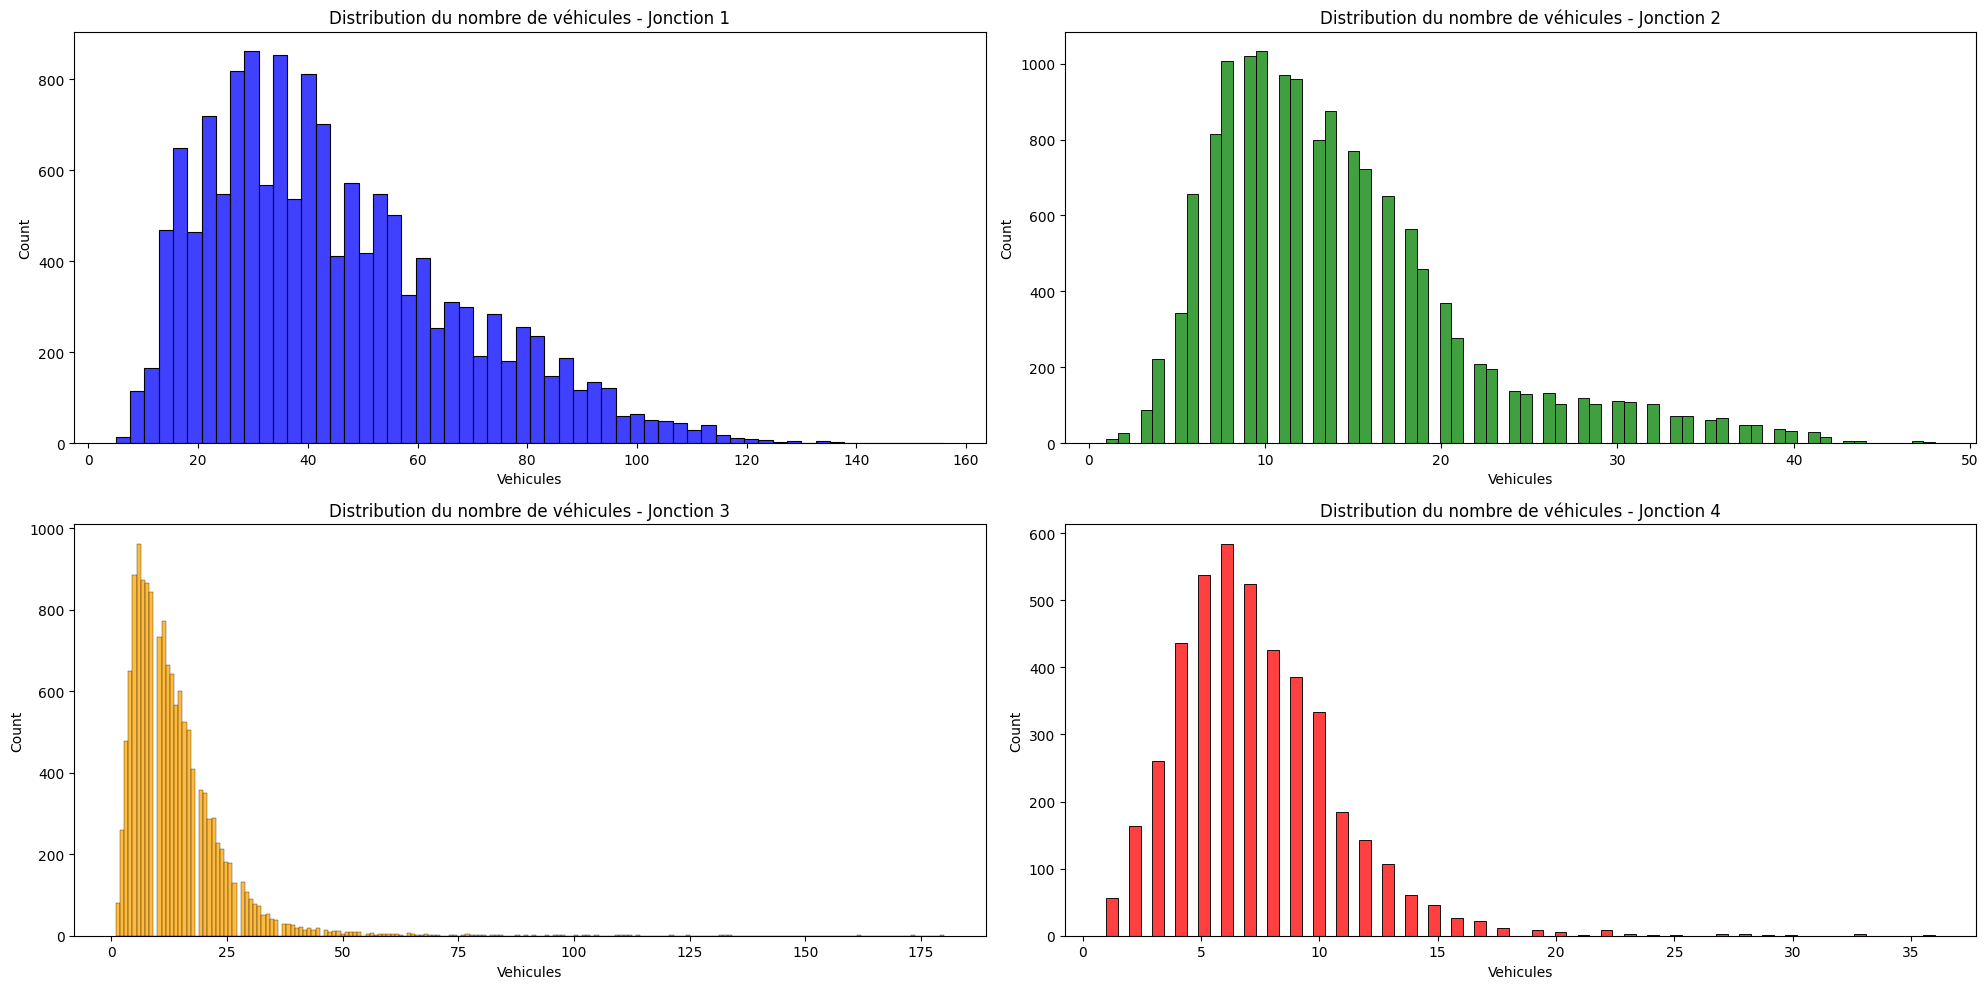

In [94]:
# Verifions la distribution du nombre de vehicules par jonctions
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
ax[0, 0].plot()
sns.histplot( data=new_data[new_data['Jonction'] == 1]["Vehicules"], ax=ax[0, 0], color='blue')
sns.histplot( data=new_data[new_data['Jonction'] == 2]["Vehicules"], ax=ax[0, 1], color='green')
sns.histplot( data=new_data[new_data['Jonction'] == 3]["Vehicules"], ax=ax[1, 0], color='orange')
sns.histplot( data=new_data[new_data['Jonction'] == 4]["Vehicules"], ax=ax[1, 1], color='red')
ax[0, 0].set_title('Distribution du nombre de véhicules - Jonction 1')
ax[0, 1].set_title('Distribution du nombre de véhicules - Jonction 2')
ax[1, 0].set_title('Distribution du nombre de véhicules - Jonction 3')
ax[1, 1].set_title('Distribution du nombre de véhicules - Jonction 4')
plt.tight_layout()  
plt.show()

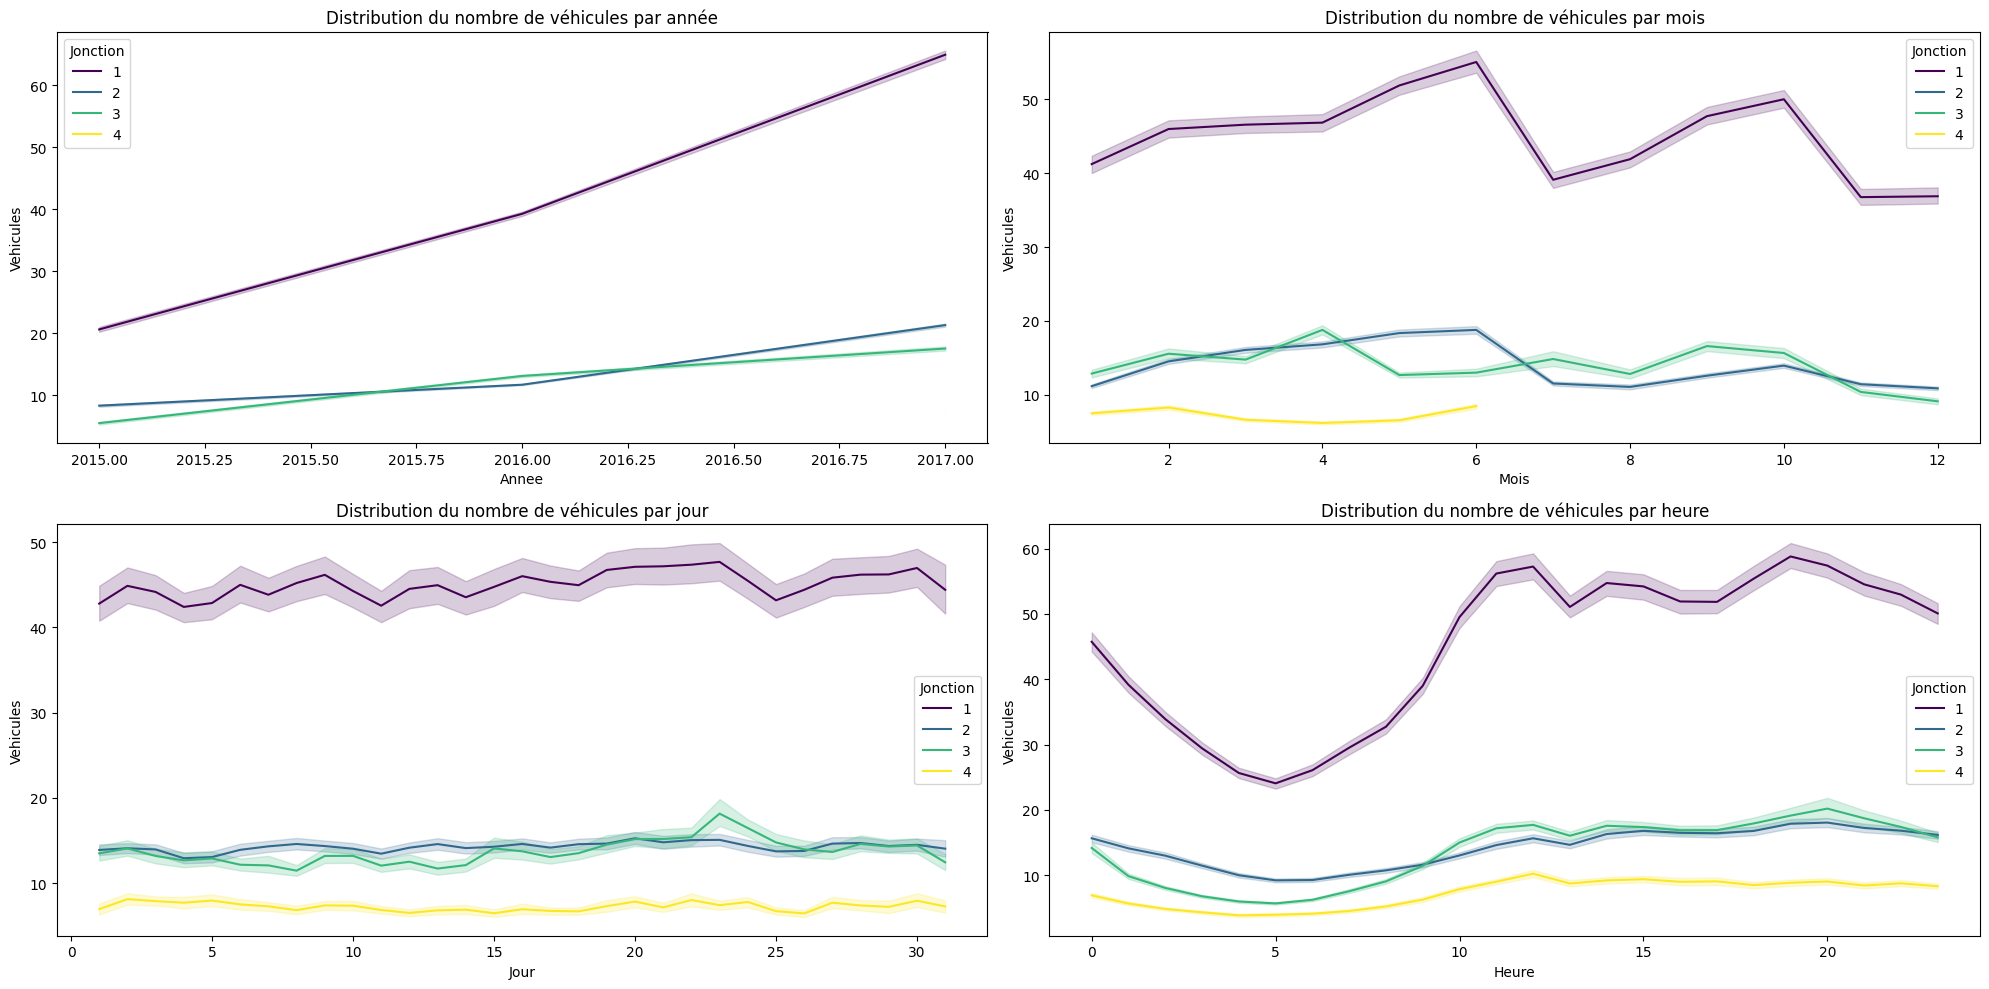

In [95]:
# Examinons l'évolution du nombre de véhicules en fonctions de nos nouvelles variables
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
sns.lineplot(data=new_data, x='Annee', y='Vehicules', ax=ax[0, 0], hue = "Jonction", palette='viridis')
sns.lineplot( data=new_data, x='Mois', y='Vehicules', ax=ax[0, 1], hue = "Jonction", palette='viridis')
sns.lineplot( data=new_data, x='Jour', y='Vehicules', ax=ax[1, 0], hue = "Jonction", palette='viridis')
sns.lineplot( data=new_data, x='Heure', y='Vehicules', ax=ax[1, 1], hue = "Jonction", palette='viridis')
ax[0, 0].set_title('Distribution du nombre de véhicules par année')
ax[0, 1].set_title('Distribution du nombre de véhicules par mois')
ax[1, 0].set_title('Distribution du nombre de véhicules par jour')
ax[1, 1].set_title('Distribution du nombre de véhicules par heure')
plt.tight_layout()  
plt.show()

# On observe sur la figure precedente que:
- Le nombre de véhicule présente une tendence haussière par anné pour toutes les jonctions à l'exception de la jonction 4 pour laquelle nous n'avons les données qu'à partir de 2017
- GLobalement, le nombre de véhicule dans ces jonctions augmente pendant le jour et diminue la nuit

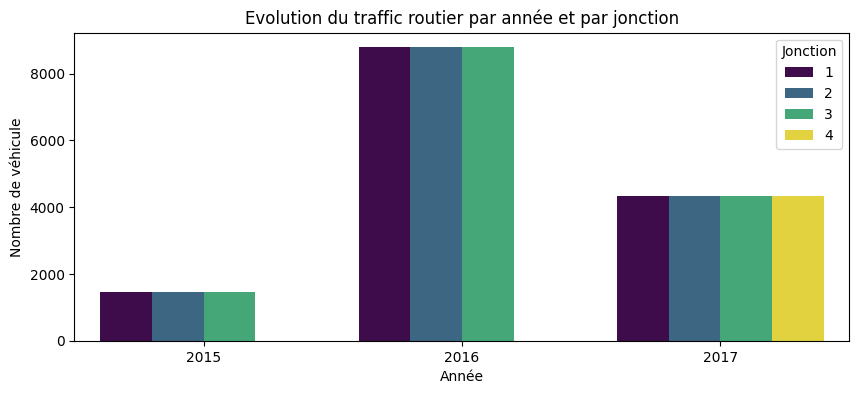

In [96]:
# Analysons l'évolution de ce traffic par année
plt.figure(figsize=(10, 4))
sns.countplot(data = new_data, x = new_data["Annee"], hue = "Jonction", palette="viridis")
plt.title("Evolution du traffic routier par année et par jonction")
plt.xlabel("Année")
plt.ylabel("Nombre de véhicule")
plt.show()

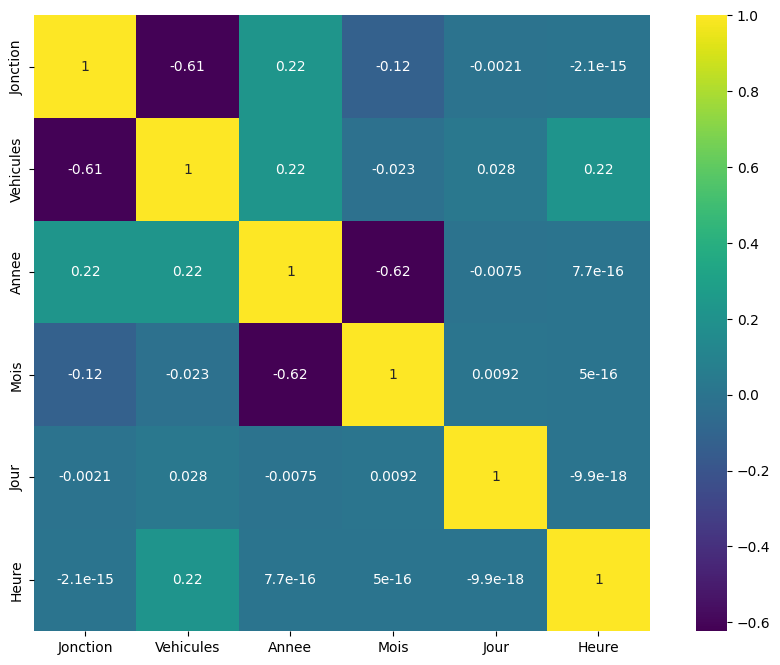

In [97]:
# Augmentation flagrante du traffic sur toutes les jonctions de 2015 à 2016

# Analyse de la correlation entre nos variables

traffic = new_data.copy()

correlations = traffic.drop("DateHeure", axis=1).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlations, cmap = "viridis", annot=True, square=True)
plt.show()

In [100]:
### Transformations de nos données pour les rendre plus adaptées à l'apprentissage automatique
# parce qu'il va falloire adapter les modeles pour chaque jonction

# Donc nous allons premierement prendre le cas de la premiere jonction pour developper le modele et comme 
# c'est la meme procedure ca ne sea pas complique de le afire pour les autres jonctions

type_jonction = 1

traffic_current = traffic[traffic["Jonction"] == type_jonction]
traffic_current.head(2)

,DateHeure,Jonction,Vehicules,Annee,Mois,Jour,Heure
0,2015-11-01 00:00:00,1,15,2015,11,1,0
1,2015-11-01 01:00:00,1,13,2015,11,1,1


<Axes: xlabel='Jour', ylabel='Vehicules'>

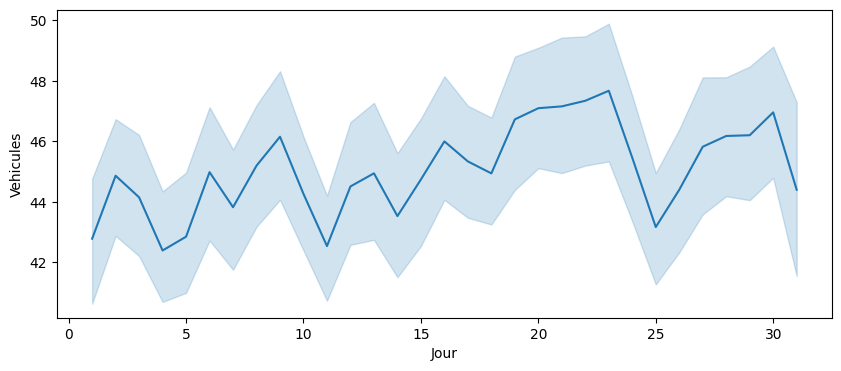

In [101]:
plt.figure(figsize=(10, 4))
sns.lineplot(x="Jour", y="Vehicules", data=traffic_current)

In [ ]:
# Normalisation des donnees avec MinMaxScaler et comme il ya de la saisonnalite on va faire la differenciation
#  Pour la jonction 1, la saisonnalite est d'une semaine, donc on va faire la differenciation avec un lag de 7 jours

In [102]:
def Normalisation(df, col):
    scaler = StandardScaler()
    df[col] = scaler.fit_transform(df[[col]])
    return df, scaler

def Difference(df,col, interval):
    diff = []
    for i in range(interval, len(df)):
        value = df[col][i] - df[col][i - interval]
        diff.append(value)
    return diff

In [103]:
traffic_current, scaler = Normalisation(traffic_current, "Vehicules")
traffic_current.head(2)

,DateHeure,Jonction,Vehicules,Annee,Mois,Jour,Heure
0,2015-11-01 00:00:00,1,-1.306219,2015,11,1,0
1,2015-11-01 01:00:00,1,-1.393147,2015,11,1,1


In [104]:
traffic_norm = traffic_current["Vehicules"].to_frame()

<Figure size 800x400 with 0 Axes>

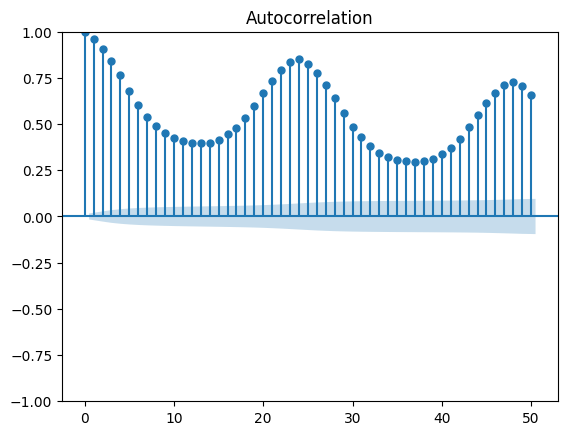

In [105]:
# Analyse des autocorrelations pour determiner les intervalles de differenciation: 
# Seasonalite (Une semaine (7 jours)))

plt.figure(figsize=(8, 4))
plot_acf(traffic_current["Vehicules"],lags=50)
plt.show()

In [106]:
Vehicules_diff = Difference(traffic_current, "Vehicules", interval= (24*7))

interval=24*7

traffic_norm = traffic_norm[interval:]

traffic_norm["Vehicules_diff"] = Vehicules_diff

traffic_traffic = traffic_norm["Vehicules_diff"].dropna()

traffic_traffic = traffic_traffic.to_frame()

traffic_traffic.head(2)

,Vehicules_diff
168,-0.086928
169,0.130392


In [107]:
traffic_traffic.shape

(14424, 1)

In [ ]:
# Etant donnée que nous somme en face des series temporelles, 
# il est important de faire le test de stationnarité des series

In [108]:
def test_stationnarite(df):
    test = adfuller(df.dropna())
    print(f"ADF Statistic: {test[0]}")
    print(f"p-value: {test[1]}")
    print("Critical Values:")
    for key, value in test[4].items():
        print('\t%s: %.3f' % (key, value))
    if test[0] > test[4]["1%"]:
        print("Les series temporelles ne sont pas stationnaires")
    else:
        print("Les series temporelles sont stationnaires") 

test_stationnarite(traffic_traffic["Vehicules_diff"])

ADF Statistic: -15.265303390415374
p-value: 4.798539876397681e-28
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567
Les series temporelles sont stationnaires


In [ ]:
# Les séries étant désormais stationnaires, nous préparons les données pour la phase de modélisation.

# Nous allons diviser les données en ensembles d'entraînement et de test, 
# en utilisant les 80% premiers points pour l'entraînement et les 20% restants pour le test.

In [124]:
def Split_data(df):
    training_size = int(len(df)*0.80)
    data_len = len(df)
    train, test = df[0:training_size],df[training_size:data_len] 
    train, test = train.values.reshape(-1, 1), test.values.reshape(-1, 1)
    return train, test
# Nous allons maintenant definir les features et les cibles pour l'apprentissage automatique tout en 
# respectant la nature temporelle de nos données donc il va falloire utiliser les retards

def Def_Features_Target(df):
    end_len = len(df)
    X = []
    y = []
    steps = 32
    for i in range(steps, end_len):
        X.append(df[i - steps:i, 0])
        y.append(df[i, 0])
    X, y = np.array(X), np.array(y)
    return X, y

# Regler les problemes de dimensions pour les modeles d'apprentissage automatique
def Correction_dimensions(train, test):
    train = np.reshape(train, (train.shape[0], train.shape[1], 1))
    test = np.reshape(test, (test.shape[0], test.shape[1], 1))
    return train, test

In [125]:
traffic_train, traffic_test = Split_data(traffic_traffic)
X_train, y_train = Def_Features_Target(traffic_train)
X_test, y_test = Def_Features_Target(traffic_test)
X_train, X_test = Correction_dimensions(X_train, X_test)

In [133]:
# NOus definions en meme temps les fonctions d'evaluation de nos modeles d'apprentissage automatique
def Evaluation_metrics(y_true, y_pred):
    metrics = {}
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    metrics["mse"] = mse
    metrics["mae"] =mae
    metrics["r2"] = r2
    metrics["rmse"] = rmse
    return pd.DataFrame([metrics])

def predictions_plot(y_true, y_pred):
    plt.figure(figsize=(10, 4))
    plt.plot(y_true, label="Valeurs réelles", color='blue')
    plt.plot(y_pred, label="Valeurs prédites", color='red')
    plt.title("Comparaison entre les valeurs réelles et prédites")
    plt.xlabel("Index")
    plt.ylabel("Nombre de véhicules")
    plt.legend()
    plt.show()

In [ ]:
########## Comme nous somme en face des sequences, on va utiliser ici 
# LSTM et GRU pour la modelisation de nos données.

In [127]:
expo_decay = ExponentialDecay(initial_learning_rate=0.01, decay_steps=10000, decay_rate=0.9)

In [128]:
X_train.shape

(11507, 32, 1)

In [129]:
y_train.shape

(11507,)

In [130]:
def MY_LSTM_MODEL(X_train, y_train, X_test, y_test):
    early_stopping = callbacks.EarlyStopping(min_delta=0.001, patience=10, restore_best_weights=True)
    model = Sequential()
    model.add(LSTM(units = 120, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(units = 60, activation='tanh', input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(0.2))
    model.add(Dense(units = 1))
    
    model.compile(optimizer=SGD(learning_rate=expo_decay, momentum=0.95), loss='mean_squared_error' )
    model.fit(X_train,y_train, validation_data=(X_test, y_test), epochs=50, batch_size=120,callbacks=[early_stopping])
    y_pred = model.predict(X_test)
    return y_pred, model



In [131]:
# Appel de notre modele LSTM pour la jonction 1
y_pred, my_lstm = MY_LSTM_MODEL(X_train, y_train, X_test, y_test)

d:\DOCUMENTS\PROJETS\Estimation-du-traffic-routier---ATUT2025\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 55s 482ms/step - loss: 0.0690 - val_loss: 0.0805
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 253ms/step - loss: 0.0577 - val_loss: 0.0746
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 40s 241ms/step - loss: 0.0550 - val_loss: 0.0714
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 38s 212ms/step - loss: 0.0535 - val_loss: 0.0693
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 256ms/step - loss: 0.0515 - val_loss: 0.0665
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 258ms/step - loss: 0.0503 - val_loss: 0.0648
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 273ms/step - loss: 0.0498 - val_loss: 0.0646
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 36s 225ms/step - loss: 0.0490 - val_loss: 0.0617
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 40s 212ms/step - loss: 0.0477 - val_loss: 0.0606
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 251ms/step - loss: 0.0477 - val_loss: 0.0597
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 304ms/step - loss: 0.0468 - val_loss: 0.0590
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 31

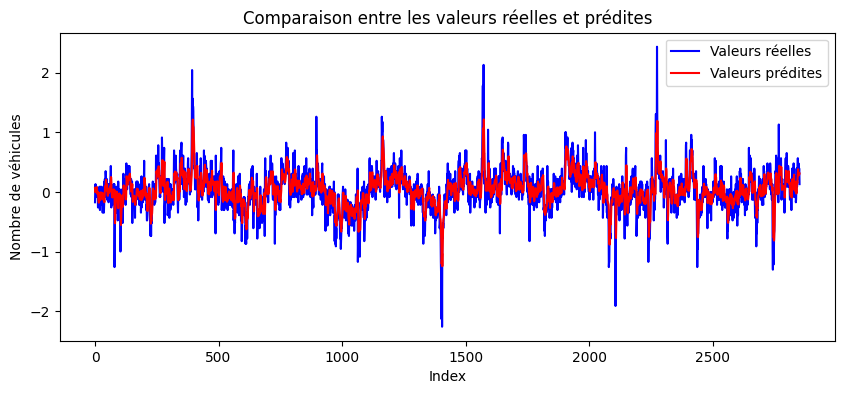

In [134]:
predictions_plot(y_test, y_pred)

In [135]:
metrics = Evaluation_metrics(y_test, y_pred)
print(metrics)

        mse       mae        r2      rmse
0  0.055825  0.170664  0.541742  0.236273


In [144]:
my_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 32, 120)        │        58,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 120)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 60)             │        43,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,123 (797.36 KB)

 Trainable params: 102,061 (398.68 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 102,062 (398.68 KB)

In [ ]:
############ Definition d'une fonction qui va nous permettre de ramener les prediction a l'etat initial

In [149]:
X_test.shape[0]

2853

In [ ]:
def recover_difference(last_ob, value):
    inversed = value + last_ob
    

In [153]:
X_test.shape[0]

2853

In [203]:
def recover_predictions(model_pred):
    recover = traffic_norm[-(X_test.shape[0] + 1):-1]
    recover["Predictions"] = model_pred
    transform_reversed = recover.Vehicules + recover.Predictions
    transform_data = transform_reversed.to_frame()
    transform_data.columns = ["Pred_normed"]
    final_pred = scaler.inverse_transform(transform_data.values)
    transform_data["Prediction_final"] = final_pred
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 1, 1)
    plt.plot(transform_data["Prediction_final"], label="Valeurs prédites", color='blue')
    plt.subplot(1, 2, 1)
    plt.plot(traffic_current["Vehicules"][-(X_test.shape[0] ):-1], label="Valeurs réelles", color='red')
    plt.legend()
    plt.show()




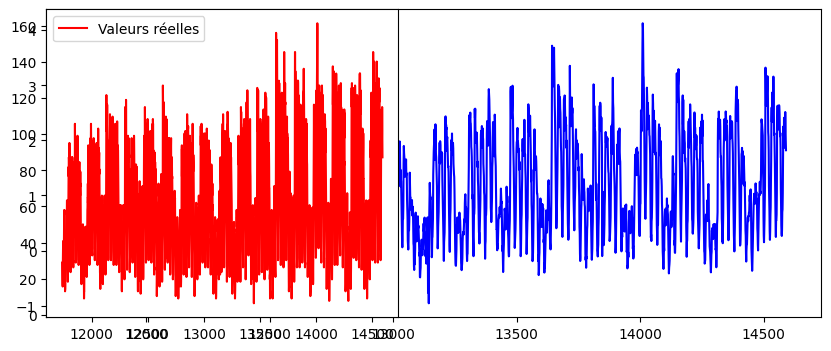

In [205]:
recover_predictions(y_pred)

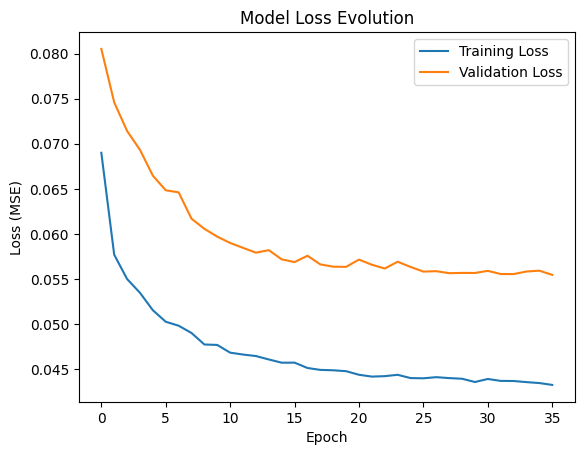

In [ ]:
plt.plot(my_lstm.history.history['loss'], label='Training Loss')
plt.plot(my_lstm.history.history['val_loss'], label='Validation Loss')
plt.title('Evolution de la fonction de perte du modèle LSTM')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
# Modelisation avec LSTM

In [137]:
def MY_GRU(X_train, y_train, X_test, y_test):
    early_stopping = callbacks.EarlyStopping(min_delta=0.001, patience=10, restore_best_weights=True)
    model_gru = Sequential()
    model_gru.add(GRU(units = 120, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model_gru.add(Dropout(0.2))
    model_gru.add(GRU(units = 60, activation='tanh', input_shape=(X_train.shape[1], 1)))
    model_gru.add(Dropout(0.2))
    model_gru.add(Dense(units = 1))
    
    model_gru.compile(optimizer=SGD(learning_rate=expo_decay, momentum=0.95), loss='mean_squared_error' )
    model_gru.fit(X_train,y_train, validation_data=(X_test, y_test), epochs=50, batch_size=120,callbacks=[early_stopping])
    gru_pred = model_gru.predict(X_test)
    return gru_pred, model_gru

In [138]:
# Appel de notre modele LSTM pour la jonction 1
gru_pred, my_gru = MY_GRU(X_train, y_train, X_test, y_test)

d:\DOCUMENTS\PROJETS\Estimation-du-traffic-routier---ATUT2025\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 272ms/step - loss: 0.0533 - val_loss: 0.0613
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 429ms/step - loss: 0.0471 - val_loss: 0.0586
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 32s 329ms/step - loss: 0.0463 - val_loss: 0.0577
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 43s 343ms/step - loss: 0.0448 - val_loss: 0.0568
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 310ms/step - loss: 0.0453 - val_loss: 0.0564
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 34s 349ms/step - loss: 0.0440 - val_loss: 0.0563
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 237ms/step - loss: 0.0441 - val_loss: 0.0561
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 233ms/step - loss: 0.0440 - val_loss: 0.0558
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 42s 239ms/step - loss: 0.0437 - val_loss: 0.0565
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 40s 226ms/step - loss: 0.0443 - val_loss: 0.0558
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 46s 278ms/step - loss: 0.0436 - val_loss: 0.0557
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 23

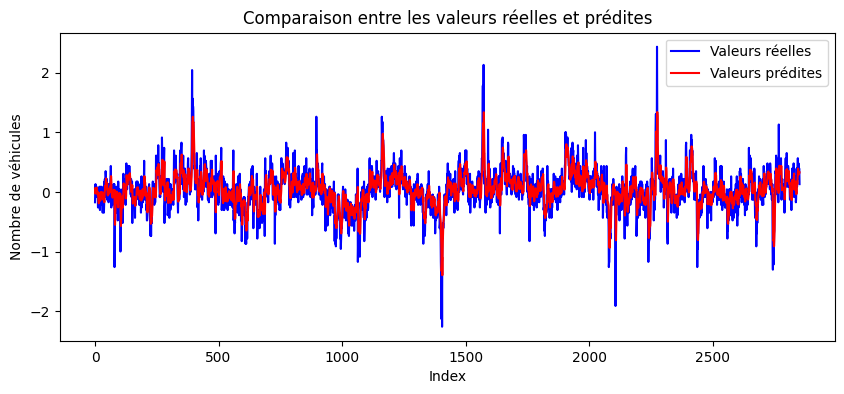

In [139]:
predictions_plot(y_test, gru_pred)

In [145]:
metrics_gru = Evaluation_metrics(y_test, gru_pred)
print(metrics_gru)

      mse       mae        r2     rmse
0  0.0558  0.171203  0.541946  0.23622


In [147]:
my_gru.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32, 120)        │        44,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32, 120)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 60)             │        32,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,203 (602.36 KB)

 Trainable params: 77,101 (301.18 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 77,102 (301.18 KB)

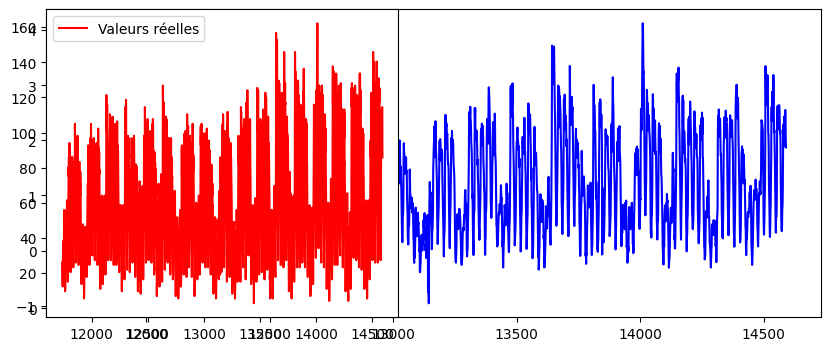

In [206]:
recover_predictions(gru_pred)

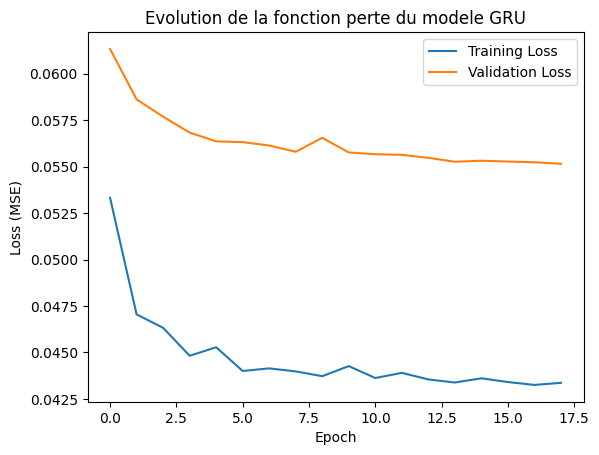

In [212]:
plt.plot(my_gru.history.history['loss'], label='Training Loss')
plt.plot(my_gru.history.history['val_loss'], label='Validation Loss')
plt.title('Evolution de la fonction perte du modele GRU')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()